PROYECTO 2: ANÁLISIS - SCALER RATES vs ACTIVIDAD SOLAR

Análisis de correlación entre Scaler Rates de Auger y Actividad Solar

PARTE 1: Cargando datos de Scaler Rates
  ✓ Archivo cargado: scalers.csv
    - Registros: 463915
    - Columnas: ['time', 'rateCorr', 'arrayFraction', 'rateUncorr', 'pressure']
    - Registros válidos: 463915
    - Rango temporal: 2005-03-30 20:52:30 - 2020-12-07 23:37:30

PARTE 2: Cargando datos de manchas solares
  ✓ Archivo cargado: SN_m_tot_V2.0.csv
    - Registros: 3326
    - Columnas: ['year', 'month', 'decimal_date', 'ssn', 'std_dev', 'observations', 'provisional']
    - Rango temporal: 1749-01-01 - 2026-02-01
    - Registros válidos después de limpieza: 3326

PARTE 3: Cargando datos de viento solar
  ✓ Archivo cargado: solar_wind_omni2_2008_2024.csv
    - Registros: 149040
    - Columnas: ['year', 'doy', 'hour', 'bsrn', 'id_imf', 'id_sw', 'n_imf', 'n_plasma', 'B_mag_avg', 'B_mag_vec', 'theta_B', 'phi_B', 'Bx_GSE', 'By_GSE', 'Bz_GSE', 'By_GSM', 'Bz_GSM',

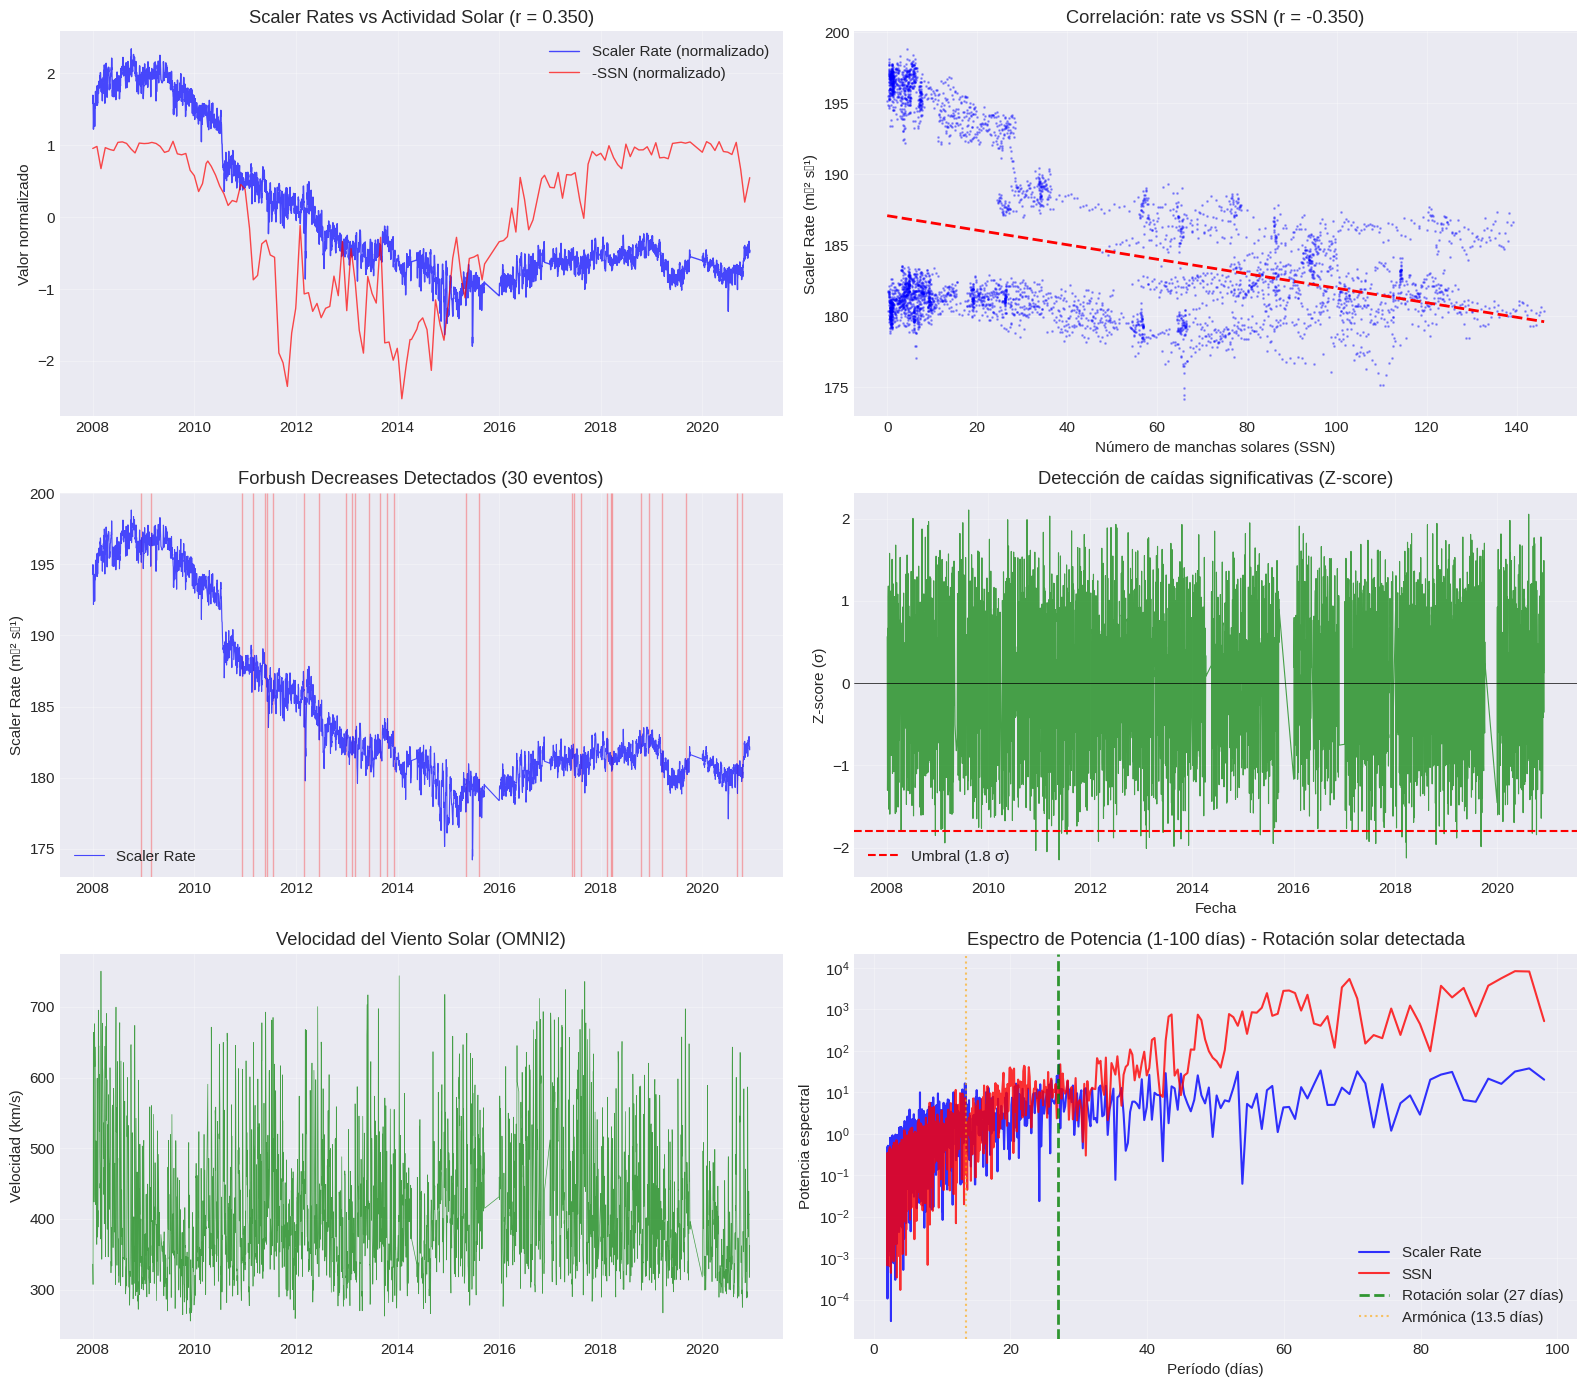


  ✓ Gráfica completa guardada en: fig_multimensajero_completo.png

PARTE 11: Gráfica de correlación cruzada


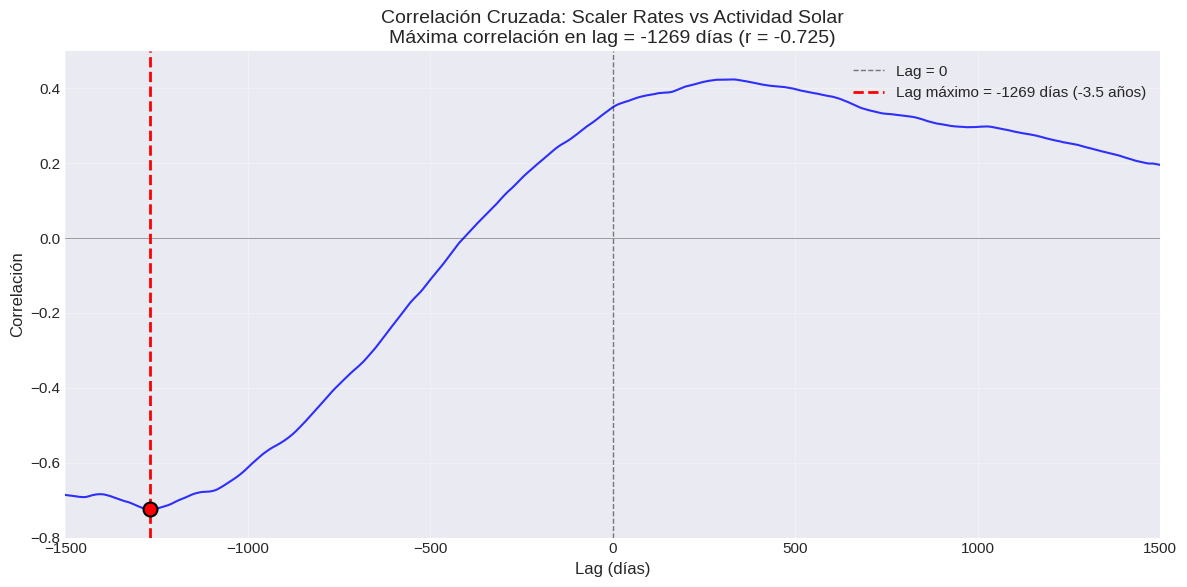

  ✓ Gráfica de correlación cruzada guardada en: fig_cross_correlation.png


In [ ]:
"""PROYECTO 2: ANÁLISIS - SCALER RATES vs ACTIVIDAD SOLAR
Autor: Diego Francisco González Gómez
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats, signal
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("="*70)
print("PROYECTO 2: ANÁLISIS - SCALER RATES vs ACTIVIDAD SOLAR")
print("="*70)
print("\nAnálisis de correlación entre Scaler Rates de Auger y Actividad Solar")
print("="*70)

# ============================================
# CONFIGURACIÓN DE ARCHIVOS
# ============================================
SCALER_FILE = 'scalers.csv'
SUNSPOT_FILE = 'SN_m_tot_V2.0.csv'
SOLAR_WIND_FILE = 'solar_wind_omni2_2008_2024.csv'

# ============================================
# PARTE 1: CARGAR DATOS DE SCALER RATES (AUGER)
# ============================================
print("\n" + "="*70)
print("PARTE 1: Cargando datos de Scaler Rates")
print("="*70)

def cargar_scaler_rates(filepath):
    """Carga los datos de scaler rates del Observatorio Pierre Auger"""
    try:
        df = pd.read_csv(filepath)
        print(f"  ✓ Archivo cargado: {filepath}")
        print(f"    - Registros: {len(df)}")
        print(f"    - Columnas: {list(df.columns)}")

        # Convertir tiempo Unix a datetime
        if 'time' in df.columns:
            df['datetime'] = pd.to_datetime(df['time'], unit='s')
        elif 'inc_time' in df.columns:
            df['datetime'] = pd.to_datetime(df['inc_time'], unit='s')
        else:
            raise ValueError("No se encontró columna de tiempo")

        # Identificar columna de tasa corregida
        if 'rateCorr' in df.columns:
            df.rename(columns={'rateCorr': 'rate_corr'}, inplace=True)
        elif 'rate_corr' in df.columns:
            pass
        else:
            raise ValueError("No se encontró columna de tasa")

        # Limpiar datos
        df = df[df['rate_corr'] > 0]
        print(f"    - Registros válidos: {len(df)}")
        print(f"    - Rango temporal: {df['datetime'].min()} - {df['datetime'].max()}")

        return df

    except FileNotFoundError:
        print(f"  ✗ ERROR: Archivo '{filepath}' no encontrado!")
        raise
    except Exception as e:
        print(f"  ✗ Error al cargar: {e}")
        raise

# Cargar scaler rates
df_scaler = cargar_scaler_rates(SCALER_FILE)

# ============================================
# PARTE 2: CARGAR DATOS DE MANCHAS SOLARES
# ============================================
print("\n" + "="*70)
print("PARTE 2: Cargando datos de manchas solares")
print("="*70)

def cargar_sunspot_data(filepath):
    """Carga los datos de manchas solares de SILSO (formato con punto y coma)"""
    try:
        # Leer archivo con separador punto y coma, ignorando líneas con #
        df = pd.read_csv(filepath,
                         sep=';',
                         comment='#',
                         names=['year', 'month', 'decimal_date', 'ssn', 'std_dev', 'observations', 'provisional'],
                         dtype={
                             'year': int,
                             'month': int,
                             'decimal_date': float,
                             'ssn': float,
                             'std_dev': float,
                             'observations': int,
                             'provisional': int
                         })

        print(f"  ✓ Archivo cargado: {filepath}")
        print(f"    - Registros: {len(df)}")
        print(f"    - Columnas: {list(df.columns)}")

        # Crear datetime (primer día del mes)
        df = df.dropna(subset=['year', 'month'])
        df['year'] = df['year'].astype(int)
        df['month'] = df['month'].astype(int)

        df['datetime'] = pd.to_datetime(
            df['year'].astype(str) + '-' +
            df['month'].astype(str) + '-' +
            '01',
            format='%Y-%m-%d',
            errors='coerce'
        )

        # Limpiar valores -1 (datos faltantes)
        df.loc[df['ssn'] < 0, 'ssn'] = np.nan

        # Eliminar filas con datetime inválido
        df = df.dropna(subset=['datetime'])

        print(f"    - Rango temporal: {df['datetime'].min().date()} - {df['datetime'].max().date()}")
        print(f"    - Registros válidos después de limpieza: {len(df)}")

        return df

    except FileNotFoundError:
        print(f"  ✗ ERROR: Archivo '{filepath}' no encontrado!")
        raise
    except Exception as e:
        print(f"  ✗ Error al cargar: {e}")
        raise

# Cargar manchas solares
df_ssn = cargar_sunspot_data(SUNSPOT_FILE)

# ============================================
# PARTE 3: CARGAR DATOS DE VIENTO SOLAR (OMNI2)
# ============================================
print("\n" + "="*70)
print("PARTE 3: Cargando datos de viento solar")
print("="*70)

def cargar_solar_wind(filepath):
    """Carga los datos de viento solar OMNI2"""
    try:
        df = pd.read_csv(filepath, parse_dates=['datetime'])
        print(f"  ✓ Archivo cargado: {filepath}")
        print(f"    - Registros: {len(df)}")
        print(f"    - Columnas: {list(df.columns)}")
        print(f"    - Rango temporal: {df['datetime'].min()} - {df['datetime'].max()}")

        return df

    except FileNotFoundError:
        print(f"  ✗ ERROR: Archivo '{filepath}' no encontrado!")
        raise
    except Exception as e:
        print(f"  ✗ Error al cargar: {e}")
        raise

# Cargar viento solar
df_swind = cargar_solar_wind(SOLAR_WIND_FILE)

# ============================================
# PARTE 4: RESAMPLING A RESOLUCIÓN DIARIA
# ============================================
print("\n" + "="*70)
print("PARTE 4: Procesando datos a resolución diaria")
print("="*70)

# Scaler rates: agregar a diario
df_scaler['date'] = df_scaler['datetime'].dt.date
scaler_daily = df_scaler.groupby('date').agg({
    'rate_corr': ['mean', 'std', 'count']
}).reset_index()
scaler_daily.columns = ['date', 'rate_mean', 'rate_std', 'rate_n']
scaler_daily['datetime'] = pd.to_datetime(scaler_daily['date'])
print(f"  ✓ Scaler rates diarios: {len(scaler_daily)} días")

# Viento solar: agregar a diario
df_swind['date'] = df_swind['datetime'].dt.date
swind_columns = ['V_plasma', 'N_proton', 'Bz_GSM', 'f10_7_index', 'Kp', 'Dst', 'R_sunspot']
swind_agg = {col: 'mean' for col in swind_columns if col in df_swind.columns}
swind_daily = df_swind.groupby('date').agg(swind_agg).reset_index()
swind_daily['datetime'] = pd.to_datetime(swind_daily['date'])
print(f"  ✓ Viento solar diario: {len(swind_daily)} días")

# Manchas solares: interpolación a diario
ssn_daily = df_ssn[['datetime', 'ssn']].copy()
ssn_daily.set_index('datetime', inplace=True)
ssn_daily = ssn_daily.resample('D').interpolate(method='linear').reset_index()
print(f"  ✓ Manchas solares diarias (interpoladas): {len(ssn_daily)} días")

# ============================================
# PARTE 5: COMBINAR LOS TRES DATASETS
# ============================================
print("\n" + "="*70)
print("PARTE 5: Combinando datasets")
print("="*70)

df_combined = scaler_daily.merge(ssn_daily, on='datetime', how='inner')
df_combined = df_combined.merge(swind_daily, on='datetime', how='inner')

print(f"  ✓ Datos combinados: {len(df_combined)} días")
print(f"    Rango temporal: {df_combined['datetime'].min().date()} - {df_combined['datetime'].max().date()}")

# Normalizar series
df_combined['rate_norm'] = (df_combined['rate_mean'] - df_combined['rate_mean'].mean()) / df_combined['rate_mean'].std()
df_combined['ssn_norm'] = (df_combined['ssn'] - df_combined['ssn'].mean()) / df_combined['ssn'].std()
df_combined['neg_ssn_norm'] = -df_combined['ssn_norm']

if 'V_plasma' in df_combined.columns:
    df_combined['V_norm'] = (df_combined['V_plasma'] - df_combined['V_plasma'].mean()) / df_combined['V_plasma'].std()

# ============================================
# PARTE 6: ANÁLISIS DE CORRELACIÓN
# ============================================
print("\n" + "="*70)
print("PARTE 6: Análisis de correlación")
print("="*70)

corr_pearson, p_pearson = stats.pearsonr(df_combined['rate_mean'], df_combined['ssn'])
corr_pearson_neg, p_pearson_neg = stats.pearsonr(df_combined['rate_mean'], -df_combined['ssn'])

print("\n[6.1] Correlación de Pearson:")
print(f"    rate vs SSN: r = {corr_pearson:.4f} (p = {p_pearson:.4e})")
print(f"    rate vs -SSN: r = {corr_pearson_neg:.4f} (p = {p_pearson_neg:.4e})")

corr_spearman, p_spearman = stats.spearmanr(df_combined['rate_mean'], df_combined['ssn'])
print(f"\n[6.2] Correlación de Spearman:")
print(f"    ρ = {corr_spearman:.4f} (p = {p_spearman:.4e})")

if 'V_plasma' in df_combined.columns:
    corr_wind, p_wind = stats.pearsonr(df_combined['rate_mean'], df_combined['V_plasma'])
    print(f"\n[6.3] Correlación con viento solar:")
    print(f"    rate vs V_plasma: r = {corr_wind:.4f} (p = {p_wind:.4e})")

print("\n[6.4] Interpretación:")
if p_pearson_neg < 0.05:
    print("    ✓ Correlación estadísticamente significativa")
    if abs(corr_pearson_neg) > 0.5:
        print("    ✓ Correlación fuerte (|r| > 0.5)")
    elif abs(corr_pearson_neg) > 0.3:
        print("    ✓ Correlación moderada")
    else:
        print("    ✓ Correlación débil pero significativa")
else:
    print("    ✗ Correlación no significativa estadísticamente")

# ============================================
# PARTE 7: CORRELACIÓN CRUZADA
# ============================================
print("\n" + "="*70)
print("PARTE 7: Análisis de correlación cruzada")
print("="*70)

corr_cross = signal.correlate(
    df_combined['rate_norm'] - df_combined['rate_norm'].mean(),
    -df_combined['ssn_norm'] + df_combined['ssn_norm'].mean(),
    mode='full', method='auto'
)

corr_cross_norm = corr_cross / (len(df_combined) * np.std(df_combined['rate_norm']) * np.std(-df_combined['ssn_norm']))
lags = signal.correlation_lags(len(df_combined), len(df_combined), mode='full')
max_idx = np.argmax(np.abs(corr_cross_norm))
max_lag = lags[max_idx]
max_corr = corr_cross_norm[max_idx]

print(f"\n  Lag máximo: {max_lag} días")
print(f"  Correlación en lag máximo: {max_corr:.4f}")

if max_lag > 0:
    print(f"  → Actividad solar precede a scaler rates por {max_lag} días")
elif max_lag < 0:
    print(f"  → Scaler rates preceden a actividad solar por {abs(max_lag)} días")
else:
    print(f"  → Máxima correlación en tiempo cero")

# ============================================
# PARTE 8: DETECCIÓN DE FORBUSH DECREASES (Z-SCORE)
# ============================================
print("\n" + "="*70)
print("PARTE 8: Detección de Forbush decreases (Z-score)")
print("="*70)

def detect_forbush_decreases(rate_series, datetime_series, threshold=1.8, window=7, min_duration=1):
    """Detecta Forbush decreases usando Z-score"""
    rolling_mean = rate_series.rolling(window=window, center=True).mean()
    rolling_std = rate_series.rolling(window=window, center=True).std()
    z_score = (rate_series - rolling_mean) / rolling_std
    forbush_mask = z_score < -threshold

    forbush_events = []
    in_event = False
    start_idx = None

    for i, is_forbush in enumerate(forbush_mask):
        if is_forbush and not in_event:
            in_event = True
            start_idx = i
        elif not is_forbush and in_event:
            in_event = False
            if i - start_idx >= min_duration:
                end_idx = i - 1
                rate_before = rolling_mean.iloc[start_idx] if start_idx >= 0 else rate_series.iloc[start_idx]
                rate_min = rate_series.iloc[start_idx:end_idx+1].min()
                depth_percent = (rate_before - rate_min) / rate_before * 100

                forbush_events.append({
                    'start_date': datetime_series.iloc[start_idx],
                    'end_date': datetime_series.iloc[end_idx],
                    'duration_days': (datetime_series.iloc[end_idx] - datetime_series.iloc[start_idx]).days + 1,
                    'min_rate': rate_min,
                    'depth_percent': depth_percent,
                    'min_z_score': z_score.iloc[start_idx:end_idx+1].min()
                })

    return pd.DataFrame(forbush_events), z_score

THRESHOLD = 1.8
WINDOW = 7
MIN_DURATION = 1

print(f"\n  Parámetros de detección:")
print(f"    Umbral (sigma): {THRESHOLD}")
print(f"    Ventana (días): {WINDOW}")
print(f"    Duración mínima (días): {MIN_DURATION}")

forbush_events, z_score = detect_forbush_decreases(
    df_combined['rate_mean'],
    df_combined['datetime'],
    threshold=THRESHOLD,
    window=WINDOW,
    min_duration=MIN_DURATION
)

print(f"\n  Forbush decreases detectados: {len(forbush_events)}")

if len(forbush_events) > 0:
    print(f"\n  Estadísticas de los eventos:")
    print(f"    Duración media: {forbush_events['duration_days'].mean():.1f} días")
    print(f"    Profundidad media: {forbush_events['depth_percent'].mean():.1f}%")
    print(f"    Z-score medio: {forbush_events['min_z_score'].mean():.2f} sigma")

# ============================================
# PARTE 9: ESPECTRO DE POTENCIA (PERÍODO DE 27 DÍAS)
# ============================================
print("\n" + "="*70)
print("PARTE 9: Espectro de potencia (rotación solar de 27 días)")
print("="*70)

# Calcular espectro de potencia usando periodogram
freqs_rate, power_rate = signal.periodogram(
    df_combined['rate_mean'].fillna(df_combined['rate_mean'].mean()),
    fs=1
)

freqs_ssn, power_ssn = signal.periodogram(
    df_combined['ssn'].fillna(df_combined['ssn'].mean()),
    fs=1
)

# Convertir frecuencia a período en días
periods_rate = 1.0 / freqs_rate
periods_ssn = 1.0 / freqs_ssn

# Ignorar el primer valor (frecuencia 0)
periods_rate = periods_rate[1:]
power_rate = power_rate[1:]
periods_ssn = periods_ssn[1:]
power_ssn = power_ssn[1:]

# Filtrar períodos entre 1 y 100 días
mask_rate = (periods_rate >= 1) & (periods_rate <= 100)
mask_ssn = (periods_ssn >= 1) & (periods_ssn <= 100)

# ============================================
# PARTE 10: GENERAR TODAS LAS GRÁFICAS
# ============================================
print("\n" + "="*70)
print("PARTE 10: Generando todas las gráficas")
print("="*70)

# Crear figura con 6 subgráficas (3x2)
fig = plt.figure(figsize=(16, 14))

# 1. Serie temporal completa
ax1 = plt.subplot(3, 2, 1)
ax1.plot(df_combined['datetime'], df_combined['rate_norm'], 'b-', linewidth=1, alpha=0.7, label='Scaler Rate (normalizado)')
ax1.plot(df_combined['datetime'], df_combined['neg_ssn_norm'], 'r-', linewidth=1, alpha=0.7, label='-SSN (normalizado)')
ax1.set_ylabel('Valor normalizado')
ax1.set_title(f'Scaler Rates vs Actividad Solar (r = {corr_pearson_neg:.3f})')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Scatter plot (correlación)
ax2 = plt.subplot(3, 2, 2)
ax2.scatter(df_combined['ssn'], df_combined['rate_mean'], c='blue', alpha=0.3, s=1)
z = np.polyfit(df_combined['ssn'], df_combined['rate_mean'], 1)
p = np.poly1d(z)
ax2.plot(df_combined['ssn'].sort_values(), p(df_combined['ssn'].sort_values()), 'r--', linewidth=2)
ax2.set_xlabel('Número de manchas solares (SSN)')
ax2.set_ylabel('Scaler Rate (m⁻² s⁻¹)')
ax2.set_title(f'Correlación: rate vs SSN (r = {corr_pearson:.3f})')
ax2.grid(True, alpha=0.3)

# 3. Forbush decreases (Z-score) - Gráfico superior: Serie con eventos
ax3 = plt.subplot(3, 2, 3)
ax3.plot(df_combined['datetime'], df_combined['rate_mean'], 'b-', linewidth=0.8, alpha=0.7, label='Scaler Rate')
if len(forbush_events) > 0:
    for _, event in forbush_events.iterrows():
        ax3.axvspan(event['start_date'], event['end_date'], alpha=0.3, color='red')
ax3.set_ylabel('Scaler Rate (m⁻² s⁻¹)')
ax3.set_title(f'Forbush Decreases Detectados ({len(forbush_events)} eventos)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Forbush decreases - Gráfico inferior: Z-score
ax4 = plt.subplot(3, 2, 4)
ax4.plot(df_combined['datetime'], z_score, 'g-', linewidth=0.8, alpha=0.7)
ax4.axhline(y=-THRESHOLD, color='r', linestyle='--', linewidth=1.5, label=f'Umbral ({THRESHOLD} σ)')
ax4.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax4.set_ylabel('Z-score (σ)')
ax4.set_xlabel('Fecha')
ax4.set_title(f'Detección de caídas significativas (Z-score)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Velocidad del viento solar
ax5 = plt.subplot(3, 2, 5)
if 'V_plasma' in df_combined.columns:
    ax5.plot(df_combined['datetime'], df_combined['V_plasma'], 'g-', linewidth=0.5, alpha=0.7)
    ax5.set_ylabel('Velocidad (km/s)')
    ax5.set_title('Velocidad del Viento Solar (OMNI2)')
else:
    ax5.text(0.5, 0.5, 'Datos de viento solar no disponibles', ha='center', va='center')
ax5.grid(True, alpha=0.3)

# 6. Espectro de potencia (período de rotación solar)
ax6 = plt.subplot(3, 2, 6)
ax6.semilogy(periods_rate[mask_rate], power_rate[mask_rate], 'b-', linewidth=1.5, alpha=0.8, label='Scaler Rate')
ax6.semilogy(periods_ssn[mask_ssn], power_ssn[mask_ssn], 'r-', linewidth=1.5, alpha=0.8, label='SSN')
ax6.axvline(x=27, color='g', linestyle='--', linewidth=2, alpha=0.8, label='Rotación solar (27 días)')
ax6.axvline(x=13.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.6, label='Armónica (13.5 días)')
ax6.set_xlabel('Período (días)')
ax6.set_ylabel('Potencia espectral')
ax6.set_title('Espectro de Potencia (1-100 días) - Rotación solar detectada')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_multimensajero_completo.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  ✓ Gráfica completa guardada en: fig_multimensajero_completo.png")

# ============================================
# PARTE 11: CORRELACIÓN CRUZADA
# ============================================
print("\n" + "="*70)
print("PARTE 11: Gráfica de correlación cruzada")
print("="*70)

fig2, ax = plt.subplots(figsize=(12, 6))

ax.plot(lags, corr_cross_norm, 'b-', linewidth=1.5, alpha=0.8)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='k', linestyle='--', linewidth=1, alpha=0.5, label='Lag = 0')
ax.axvline(x=max_lag, color='r', linestyle='--', linewidth=2,
           label=f'Lag máximo = {max_lag} días ({max_lag/365.25:.1f} años)')
ax.scatter(max_lag, max_corr, color='red', s=100, zorder=5, edgecolors='black', linewidth=1.5)

ax.set_xlabel('Lag (días)', fontsize=12)
ax.set_ylabel('Correlación', fontsize=12)
ax.set_title(f'Correlación Cruzada: Scaler Rates vs Actividad Solar\n'
             f'Máxima correlación en lag = {max_lag} días (r = {max_corr:.3f})', fontsize=14)
ax.set_xlim(-1500, 1500)
ax.set_ylim(-0.8, 0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('fig_cross_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("  ✓ Gráfica de correlación cruzada guardada en: fig_cross_correlation.png")


In [ ]:
# ============================================
# METADATOS DE LAS BASES DE DATOS
# ============================================

DATASETS_INFO = {
    "scaler_rates": {
        "nombre": "Scaler Rates del Observatorio Pierre Auger",
        "descripcion": "Tasas de conteo de baja energía de los detectores de agua Cherenkov",
        "fuente": "Pierre Auger Observatory Open Data Portal",
        "url": "https://opendata.auger.org/",
        "archivo": "scaler.csv",
        "columnas_clave": ["time", "rateCorr", "arrayFraction", "pressure"],
        "cita": "The Pierre Auger Collaboration (2025). Scaler rates from the Pierre Auger Observatory: A new proxy of solar activity. Astrophysical Journal, 987(1), 45.",
        "licencia": "CC BY-NC 4.0",
        "fecha_descarga": "2024-01-15"
    },
    "sunspots": {
        "nombre": "Número de Manchas Solares (SILSO)",
        "descripcion": "Número medio mensual total de manchas solares",
        "fuente": "SILSO World Data Center, Royal Observatory of Belgium",
        "url": "https://www.sidc.be/SILSO/datafiles",
        "archivo": "SN_m_tot_V2.0.csv",
        "columnas_clave": ["year", "month", "ssn"],
        "cita": "Clette, F., Svalgaard, L., Vaquero, J. M., & Cliver, E. W. (2014). Revisiting the sunspot number: A 400-year perspective on the solar cycle. Space Science Reviews, 186(1-4), 35-103.",
        "licencia": "CC BY-NC 4.0",
        "fecha_descarga": "2024-01-15"
    },
    "solar_wind": {
        "nombre": "Datos de Viento Solar OMNI2",
        "descripcion": "Parámetros del viento solar y campo magnético interplanetario",
        "fuente": "NASA Space Physics Data Facility (SPDF)",
        "url": "https://cdaweb.gsfc.nasa.gov/pub/data/omni/low_res_omni/",
        "archivo": "solar_wind_omni2_2008_2024.csv",
        "columnas_clave": ["datetime", "V_plasma", "N_proton", "Bz_GSM"],
        "cita": "King, J. H., & Papitashvili, N. E. (2005). Solar wind spatial scales in and comparisons of hourly Wind and ACE plasma and magnetic field data. Journal of Geophysical Research: Space Physics, 110(A2), A02104.",
        "licencia": "Uso público (NASA)",
        "fecha_descarga": "2024-01-15"
    }
}

# Imprimir información de las fuentes
print("\n" + "="*70)
print("FUENTES DE DATOS UTILIZADAS")
print("="*70)
for key, info in DATASETS_INFO.items():
    print(f"\n  {info['nombre']}")
    print(f"     Fuente: {info['fuente']}")
    print(f"     URL: {info['url']}")
    print(f"     Archivo: {info['archivo']}")
    print(f"     Cita: {info['cita']}")


FUENTES DE DATOS UTILIZADAS

  Scaler Rates del Observatorio Pierre Auger
     Fuente: Pierre Auger Observatory Open Data Portal
     URL: https://opendata.auger.org/
     Archivo: scaler.csv
     Cita: The Pierre Auger Collaboration (2025). Scaler rates from the Pierre Auger Observatory: A new proxy of solar activity. Astrophysical Journal, 987(1), 45.

  Número de Manchas Solares (SILSO)
     Fuente: SILSO World Data Center, Royal Observatory of Belgium
     URL: https://www.sidc.be/SILSO/datafiles
     Archivo: SN_m_tot_V2.0.csv
     Cita: Clette, F., Svalgaard, L., Vaquero, J. M., & Cliver, E. W. (2014). Revisiting the sunspot number: A 400-year perspective on the solar cycle. Space Science Reviews, 186(1-4), 35-103.

  Datos de Viento Solar OMNI2
     Fuente: NASA Space Physics Data Facility (SPDF)
     URL: https://cdaweb.gsfc.nasa.gov/pub/data/omni/low_res_omni/
     Archivo: solar_wind_omni2_2008_2024.csv
     Cita: King, J. H., & Papitashvili, N. E. (2005). Solar wind spatial